In [ ]:
!pip install catboost
import os
import pandas as pd
import numpy as np
import gdown
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import catboost as cb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [ ]:
url_train = "https://drive.google.com/uc?id=159PZX3X5rpUO-WbzWyC9whnc8B4mNqJl&export=download"
url_test  = "https://drive.google.com/uc?id=1Ui2t87X3in-Wu-pnjkDXa_VtPsVafi0l&export=download"

output_file_train = "train.csv"
output_file_test  = "test.csv"

gdown.download(url_train, output_file_train, quiet=False)
gdown.download(url_test, output_file_test, quiet=False)


df_train = pd.read_csv(output_file_train)
df_test = pd.read_csv(output_file_test)

print("\ndf_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

print("\nTrain columns:")
print(df_train.columns.tolist())

print("\nTest columns:")
print(df_test.columns.tolist())

print("\nDtypes:")
print(df_train.dtypes.head(30))

print("\nTrain head:")
display(df_train.head())



Downloading...
From: https://drive.google.com/uc?id=159PZX3X5rpUO-WbzWyC9whnc8B4mNqJl&export=download
To: /content/train.csv
100%|██████████| 1.36M/1.36M [00:00<00:00, 92.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ui2t87X3in-Wu-pnjkDXa_VtPsVafi0l&export=download
To: /content/test.csv
100%|██████████| 441k/441k [00:00<00:00, 15.1MB/s]



df_train shape: (751, 214)
df_test shape: (250, 211)

Train columns:
['index', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_V

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


Train: 751 строка, 214 колонок (3 таргета + index + 210 числовых признаков)

Test: 250 строк, 211 колонок (без таргетов)

Таргеты в train называются 'IC50, mM' и 'CC50, mM' — нужно переименовать

Все признаки — готовые числовые  (float64/int64)

Переименуем таргеты и посмотрим describe

In [ ]:
df_train = df_train.rename(columns={
    'IC50, mM': 'IC50',
    'CC50, mM': 'CC50'
})

targets = ['IC50','CC50', 'SI']

existing_targets = [c for c in targets if c in df_train.columns]
print("\nНайденные таргеты:", existing_targets)

if existing_targets:
    print("\nПропуски в таргетах:")
    print(df_train[existing_targets].isna().sum())

    print("\nDescribe по таргетам:")
    display(df_train[existing_targets].describe())



Найденные таргеты: ['IC50', 'CC50', 'SI']

Пропуски в таргетах:
IC50    0
CC50    0
SI      0
dtype: int64

Describe по таргетам:


,IC50,CC50,SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


IC50 (концентрация подавления вируса)
751 наблюдение, пропусков нет
Медиана = 44.07
Среднее = 204.54 — больше, чем  в 4 раза выше медианы, что говорит о сильном влиянии выбросов
Диапазон от 0.003 до 4095— разброс в 1 миллион раз. Это очень много.
Распределение сильно скошено вправо, необходимо логарифмирование перед обучением.

CC50	(концентрация токсичности для клеток)
751 наблюдение, пропусков нет
Медиана = 376.58, заметно выше медианы IC50, что логически корректно
Среднее = 577.43, в 1.5 раза выше медианы
Диапазон от 0.7 до 4539
CC50 > IC50 почти всегда, иначе токсичность наступает при большей концентрации чем подавление вируса
Распределение правостороннее, но менее экстремальное чем IC50

SI(Selectivity Index) — индекс селективности
751 наблюдение, пропусков нет
Медиана = 4.0, т.е. 50% молекул имеют SI ≤ 4, то есть слабую селективность
75% молекул имеют SI ≤ 17.4
Среднее = 89.15 — в 22 раза выше медианы
Максимум = 15620 —  скорее всего единичные молекулы с уникальной селективностью.
Самый нестабильный таргет с экстремальными выбросами, потенциально источник ошибок при построении модели



Удаляем индексный столбец, т.к. он не нужен для дальнейшей работы.


In [ ]:
df_train.drop(columns='index', inplace=True)
print("Удалён столбец 'index'")

Удалён столбец 'index'


Посмотрим, есть ли пропуски

In [ ]:
df_train = df_train.dropna(how='all')


missing_per_column = df_train.isnull().sum()
cols_with_nan = missing_per_column[missing_per_column > 0].index.tolist()


if cols_with_nan:
    print(f"Столбцов с пропусками: {len(cols_with_nan)}")
    print("Число пропусков по этим столбцам:")
    print(missing_per_column[missing_per_column > 0])


    n_rows_before = len(df_train)
    rows_with_nans_mask = df_train[cols_with_nan].isnull().any(axis=1)
    n_rows_with_nans = rows_with_nans_mask.sum()
    print(f"Строк с пропусками: {n_rows_with_nans}")

Столбцов с пропусками: 12
Число пропусков по этим столбцам:
MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64
Строк с пропусками: 2


Пропуски есть, объем пропусков небольшой, поэтому принято решение удалить.
Также было протестировано, что балл на Kaggle при заполнении пропусков медианой хуже. Скорее всего это происходит потому что выбрасывание строк с пропусками даёт модели «чище» сигнал и лучше скор, чем грубое заполнение медианой, потому что медиана вносит систематический шум и искажает распределения и связи признаков с таргетом.


Посмотрим есть ли столбцы константами.
Их логично удалить, т.к.они не несут информации для разделения классов/прогноза и только раздувают размерность, как следствие замедляют обучение.

In [ ]:
constant_cols = []
for col in df_train.columns:
    if df_train[col].nunique() == 1:
        constant_cols.append(col)

print(f"Константы({len(constant_cols)}):")
for col in constant_cols:
    print(f"  {col}: {df_train[col].iloc[0]}")

df_train.drop(columns=constant_cols, inplace=True)
df_test.drop(columns=constant_cols, inplace=True, errors='ignore')

print(f"Размер train после удаления констант: {df_train.shape}")
print(f"Размер test после удаления констант:  {df_test.shape}")

Константы(18):
  NumRadicalElectrons: 0
  SMR_VSA8: 0
  SlogP_VSA9: 0
  fr_N_O: 0
  fr_SH: 0
  fr_azide: 0
  fr_barbitur: 0
  fr_benzodiazepine: 0
  fr_diazo: 0
  fr_dihydropyridine: 0
  fr_isocyan: 0
  fr_isothiocyan: 0
  fr_lactam: 0
  fr_nitroso: 0
  fr_phos_acid: 0
  fr_phos_ester: 0
  fr_prisulfonamd: 0
  fr_thiocyan: 0
Размер train после удаления констант: (751, 195)
Размер test после удаления констант:  (250, 193)


В этой версии датасета все столбцы имеют больше одного уникального значения, соответственно констант для удаления нет.
И есть разница между train и test на 2 колонки. Это то, о чем было указано в задании и приведен формат sample для загрузки.

Посмотрим дубликаты по столбцам и строкам

In [ ]:
feature_cols = [c for c in df_train.columns if c not in targets]

duplicate_cols = []
seen = {}
for col in feature_cols:
    col_hash = tuple(df_train[col].values)
    if col_hash in seen:
        duplicate_cols.append(col)
    else:
        seen[col_hash] = col

if duplicate_cols:
    print(duplicate_cols)
    df_train.drop(columns=duplicate_cols, inplace=True)
    df_test.drop(columns=duplicate_cols, inplace=True, errors='ignore')
    print(f"train после: {df_train.shape}")

before = len(df_train)
df_train.drop_duplicates(inplace=True)
print(f"train после: {df_train.shape}")

print(f"Признаков:{len(feature_cols)}")


['MaxEStateIndex', 'fr_COO2', 'fr_Nhpyrrole', 'fr_benzene', 'fr_nitro_arom_nonortho', 'fr_phenol_noOrthoHbond']
train после: (751, 189)
train после: (736, 189)
Признаков:192


Удалили явные дубликаты, 15 строк. Всего 186 признаков.

И сразу посмотрим файл sample_submission, чтобы понимать итоговый формат для загрузки на Kaggle и название колонок

In [ ]:
url_sample = "https://drive.google.com/uc?id=1LL6moSzpUVxJUTMeXihWvUxBJNjvj6EH&export=download"
output_file_sample = "sample_submission.csv"

gdown.download(url_sample, output_file_sample, quiet=False)

sample_sub= pd.read_csv(output_file_sample)

print("\nSample submission shape:", sample_sub.shape)
print("Sample submission columns:")
print(sample_sub.columns.tolist())

print("\nSample head:")
display(sample_sub.head())

id_col =sample_sub.columns[0]
print(f"Имя ID в sample_submission: {id_col}")


Downloading...
From: https://drive.google.com/uc?id=1LL6moSzpUVxJUTMeXihWvUxBJNjvj6EH&export=download
To: /content/sample_submission.csv
100%|██████████| 15.4k/15.4k [00:00<00:00, 28.7MB/s]


Sample submission shape: (250, 4)
Sample submission columns:
['index', 'IC50', 'CC50', 'SI']

Sample head:


,index,IC50,CC50,SI
0,0,0.723678,0.426328,0.308486
1,1,0.804617,0.643166,0.179750
2,2,0.907425,0.518521,0.298384
3,3,0.563266,0.054770,0.280019
4,4,0.935028,0.616856,0.979752


Имя ID в sample_submission: index


Переходим к масштабированию

In [ ]:
targets = ['IC50', 'CC50', 'SI']
feature_cols = [c for c in df_train.columns if c not in targets and c != 'index']
X = df_train[feature_cols].copy()

numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X_test_raw = df_test[feature_cols].copy()
X_test_scaled = X_test_raw.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test_raw[numeric_cols])

y_ic50 =np.log1p(df_train['IC50'])
y_cc50=np.log1p(df_train['CC50'])
y_si= np.log1p(df_train['SI'])

print(f"X_scaled shape: {X_scaled.shape}")


X_scaled shape: (736, 186)


А теперь необходимо отобрать признаки.
Для отбора проранжируем их по важности по каждому таргету

In [ ]:
def get_selected_features(X_scaled, y, target_name, threshold=0.95):
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)

    imp_df = pd.DataFrame({
        'признак': X_scaled.columns,
        'важность': rf.feature_importances_
    }).sort_values('важность', ascending=False).reset_index(drop=True)

    imp_df['cumulative_importance'] = imp_df['важность'].cumsum()
    k = (imp_df['cumulative_importance'] < threshold).sum() + 1
    selected = imp_df.head(k)['признак'].tolist()

    print(f"{target_name}: топ-10 признаков:")
    print(imp_df.head(10)[['признак', 'важность']].to_string(index=False))
    print(f"\nДля {int(threshold*100)}% важности нужно признаков: {k}")

    return selected, imp_df

selected_ic50, imp_ic50 = get_selected_features(X_scaled, y_ic50, 'IC50')
selected_cc50, imp_cc50 = get_selected_features(X_scaled, y_cc50, 'CC50')
selected_si, imp_si= get_selected_features(X_scaled, y_si, 'SI')


IC50: топ-10 признаков:
         признак  важность
     VSA_EState8  0.082513
     VSA_EState6  0.066549
    BCUT2D_MRLOW  0.033241
     VSA_EState4  0.031741
     EState_VSA5  0.021263
     EState_VSA8  0.019980
         MolLogP  0.019568
        BalabanJ  0.019197
FpDensityMorgan1  0.019189
     EState_VSA3  0.018638

Для 95% важности нужно признаков: 94
CC50: топ-10 признаков:
         признак  важность
          Kappa1  0.040220
    BCUT2D_MWLOW  0.039475
          Kappa3  0.033952
     VSA_EState6  0.025453
             SPS  0.024898
       NHOHCount  0.024667
FpDensityMorgan1  0.023502
          Kappa2  0.023259
     VSA_EState8  0.020569
     VSA_EState4  0.020076

Для 95% важности нужно признаков: 105
SI: топ-10 признаков:
       признак  важность
   VSA_EState6  0.142889
  FractionCSP3  0.059735
  BCUT2D_CHGLO  0.034715
   VSA_EState8  0.034003
           qed  0.025009
BCUT2D_LOGPLOW  0.022513
   VSA_EState9  0.020862
 BCUT2D_LOGPHI  0.020861
  BCUT2D_MRLOW  0.020204
      SMR

IC50 (93 признака из 186):
Топ признак: BCUT2D_MWLOW (0.090)
Нужно 93 признака для 95% важности — признаки распределены равномерно

CC50 (87 признаков из 186):
Топ признак: LabuteASA (0.105) —
Похожий набор признаков на IC50, но с другими весами

SI (52 признака из 186):
Топ признак: VSA_EState6 (0.607) — объясняет 60% важности единственный признак с таким %.
Нужно всего 52 признака — SI зависит от меньшего числа дескрипторов

Формируем датасеты

In [ ]:
X_train_ic50 =X_scaled[selected_ic50]
X_train_cc50= X_scaled[selected_cc50]
X_train_si= X_scaled[selected_si]

X_test_ic50 = X_test_scaled[selected_ic50]
X_test_cc50= X_test_scaled[selected_cc50]
X_test_si= X_test_scaled[selected_si]

print(f"X_train_ic50:{X_train_ic50.shape}")
print(f"X_train_cc50:{X_train_cc50.shape}")
print(f"X_train_si: {X_train_si.shape}")
print(f"\nX_test_ic50:{X_test_ic50.shape}")
print(f"X_test_cc50:{X_test_cc50.shape}")
print(f"X_test_si:{X_test_si.shape}")


X_train_ic50:(736, 94)
X_train_cc50:(736, 105)
X_train_si: (736, 92)

X_test_ic50:(250, 94)
X_test_cc50:(250, 105)
X_test_si:(250, 92)


Теперь логарифмируем таргеты и  переходим к обучению

In [ ]:
seed = 42
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

y_ic50_log = y_ic50
y_cc50_log = y_cc50
y_si_log= y_si


for name, X_tr, y_log in [
    ('IC50', X_train_ic50, y_ic50_log),
    ('CC50', X_train_cc50, y_cc50_log),
    ('SI',   X_train_si,   y_si_log)
]:
    rf = RandomForestRegressor(n_estimators=100, random_state=seed, n_jobs=-1)
    scores = cross_val_score(rf, X_tr, y_log, cv=kf,
                             scoring='neg_root_mean_squared_error')
    rmse = -scores
    print(f"{name}:")
    print(f"RMSE по фолдам:{rmse.round(4)}")
    print(f"Среднее RMSE:{rmse.mean():.4f} ± {rmse.std():.4f}\n")

IC50:
RMSE по фолдам:[1.3822 1.522  1.5616 1.5767 1.366 ]
Среднее RMSE:1.4817 ± 0.0898

CC50:
RMSE по фолдам:[1.1275 1.199  1.3694 1.2785 1.1815]
Среднее RMSE:1.2312 ± 0.0844

SI:
RMSE по фолдам:[1.148  1.2656 1.489  1.0457 1.284 ]
Среднее RMSE:1.2465 ± 0.1487



IC50 — наибольшая ошибка (1.4897):
   - Самый сложный для предсказания таргет
   - std=0.086 — умеренная стабильность между фолдами

2. CC50 — лучший результат (1.2360):
   - Модель предсказывает CC50 точнее всего
   - std=0.082 — стабильный результат

3. SI — средняя ошибка (1.2448) но самая высокая нестабильность:
   - std=0.159 — результат сильно меняется между фолдами
   - Это ожидаемо — SI имеет экстремальные выбросы до 15620
   - Нестабильность говорит о том что в разных фолдах
     попадается разное количество выбросов

Теперь обучаем LightGBM и CatBoost,
сравниваем с RandomForest и строим ансамбль.
Берем именно Boost, потому что уже очевидно, что  у нас нелинейные      зависимости между дескрипторами и таргетом, нам нужна модель наименее чувствительная к выбросам и учитывающая комбинации признаков.


**Total стратегия:**

Модель 1 (IC50): ансамбль RF + LGBM + CatBoost

Модель 2 (CC50): ансамбль RF + LGBM + CatBoost

Модель 3 (SI):   ансамбль RF + LGBM + CatBoost

In [ ]:
seed = 42
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

y_ic50_log = y_ic50
y_cc50_log = y_cc50
y_si_log = y_si

models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300, random_state=seed, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        random_state=seed, n_jobs=-1, verbose=-1
    ),
    'CatBoost': cb.CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6,
        random_seed=seed, verbose=0
    )
}

def cv_rmse(model, X, y, kf):
    scores = []
    for tr, val in kf.split(X):
        model.fit(X.iloc[tr], y.iloc[tr])
        preds =model.predict(X.iloc[val])
        scores.append(np.sqrt(mean_squared_error(y.iloc[val], preds)))
    return np.array(scores)

results = {}

for target_name, X_tr, y_log in [
    ('IC50',X_train_ic50, y_ic50_log),
    ('CC50',X_train_cc50, y_cc50_log),
    ('SI', X_train_si,   y_si_log)
]:
    results[target_name] = {}
    print(f"{target_name}")
    for model_name, model in models.items():
        scores = cv_rmse(model, X_tr, y_log, kf)
        results[target_name][model_name] = scores.mean()
        print(f"{model_name:<15}: {scores.mean():.4f} ± {scores.std():.4f}")
    print()

IC50
  RandomForest   : 1.4785 ± 0.0926
  LightGBM       : 1.5719 ± 0.1094
  CatBoost       : 1.4890 ± 0.0847

CC50
  RandomForest   : 1.2212 ± 0.0860
  LightGBM       : 1.2664 ± 0.0739
  CatBoost       : 1.2431 ± 0.0846

SI
  RandomForest   : 1.2430 ± 0.1500
  LightGBM       : 1.2935 ± 0.1493
  CatBoost       : 1.2598 ± 0.1464



RandomForest выигрывает по всем трём таргетам с дефолтными параметрами.

LightGBM показывает худший результат,что предсказуемо для небольших датасетов (736 строк).

теперь строим Ансамбль, чтобы улучшить результат каждой модели и "усреднить" дисперсию


Стратегия 1. Берем равные веса 1/3, нейтральная позиция

Стратегия 2. 0,5 - отдаем лучшей модели, где RMSE ниже

Стратегия 3. 0,6 - отдаем лучшей модели,чтобы она вносила бОльший вклад

In [ ]:
seed = 42
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

def cv_ensemble(models_list, weights, X, y, kf):
    scores = []
    for tr, val in kf.split(X):
        X_tr, X_val = X.iloc[tr], X.iloc[val]
        y_tr, y_val = y.iloc[tr], y.iloc[val]
        preds = np.zeros(len(val))
        for model, w in zip(models_list, weights):
            model.fit(X_tr, y_tr)
            preds += w * model.predict(X_val)
        scores.append(np.sqrt(mean_squared_error(y_val, preds)))
    return np.array(scores)

rf_model  = lambda: RandomForestRegressor(n_estimators=300, random_state=seed, n_jobs=-1)
lgb_model = lambda: lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=seed, n_jobs=-1, verbose=-1)
cat_model = lambda: cb.CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=seed, verbose=0)

## IC50
for weights, label in [
    ([1/3, 1/3, 1/3], "RF+LGBM+CatBoost (равные)"),
    ([0.5, 0.25, 0.25], "RF+LGBM+CatBoost (0.5/0.25/0.25)"),
    ([0.6, 0.2, 0.2], "RF+LGBM+CatBoost (0.6/0.2/0.2)"),
]:
    s = cv_ensemble([rf_model(), lgb_model(), cat_model()], weights, X_train_ic50, y_ic50_log, kf)
    print(f"  {label}: {s.mean():.4f} ± {s.std():.4f}")
print(f"  RF одиночный: 1.4773")

## CC50
for weights, label in [
    ([1/3, 1/3, 1/3], "RF+LGBM+CatBoost (равные)"),
    ([0.5, 0.25, 0.25], "RF+LGBM+CatBoost (0.5/0.25/0.25)"),
    ([0.6, 0.2, 0.2], "RF+LGBM+CatBoost (0.6/0.2/0.2)"),
]:
    s = cv_ensemble([rf_model(), lgb_model(), cat_model()], weights, X_train_cc50, y_cc50_log, kf)
    print(f"  {label}: {s.mean():.4f} ± {s.std():.4f}")
print(f"  RF одиночный: 1.2260")

##SI
for weights, label in [
    ([1/3, 1/3, 1/3], "RF+LGBM+CatBoost (равные)"),
    ([0.5, 0.25, 0.25], "RF+LGBM+CatBoost (0.5/0.25/0.25)"),
    ([0.6, 0.2, 0.2], "RF+LGBM+CatBoost (0.6/0.2/0.2)"),
]:
    s = cv_ensemble([rf_model(), lgb_model(), cat_model()], weights, X_train_si, y_si_log, kf)
    print(f"  {label}: {s.mean():.4f} ± {s.std():.4f}")
print(f"  RF одиночный: 1.2492")

  RF+LGBM+CatBoost (равные): 1.4943 ± 0.0965
  RF+LGBM+CatBoost (0.5/0.25/0.25): 1.4874 ± 0.0954
  RF+LGBM+CatBoost (0.6/0.2/0.2): 1.4841 ± 0.0948
  RF одиночный: 1.4773
  RF+LGBM+CatBoost (равные): 1.2300 ± 0.0829
  RF+LGBM+CatBoost (0.5/0.25/0.25): 1.2254 ± 0.0838
  RF+LGBM+CatBoost (0.6/0.2/0.2): 1.2234 ± 0.0844
  RF одиночный: 1.2260
  RF+LGBM+CatBoost (равные): 1.2513 ± 0.1515
  RF+LGBM+CatBoost (0.5/0.25/0.25): 1.2470 ± 0.1515
  RF+LGBM+CatBoost (0.6/0.2/0.2): 1.2451 ± 0.1514
  RF одиночный: 1.2492


По итогам ансамбля:

для IC50
берём одиночный RandomForest, лучший результат - 1.4773

для CC50
 лучший результат - ансамбль 0.6/0.2/0.2: 1.2234
берем RF*0.6 + LGBM*0.2 + CatBoost*0.2

для SI
лучший результат- ансамбль 0.6/0.2/0.2: 1.2451
берем ансамбль RF*0.6 + LGBM*0.2 + CatBoost*0.2


Обучаем train

In [ ]:
seed = 42

## IC50
rf_ic50 = RandomForestRegressor(n_estimators=300, random_state=seed, n_jobs=-1)
rf_ic50.fit(X_train_ic50, y_ic50_log)

## CC50
rf_cc50  = RandomForestRegressor(n_estimators=300, random_state=seed, n_jobs=-1)
lgb_cc50 = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=seed, n_jobs=-1, verbose=-1)
cat_cc50 = cb.CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=seed, verbose=0)
rf_cc50.fit(X_train_cc50, y_cc50_log)
lgb_cc50.fit(X_train_cc50, y_cc50_log)
cat_cc50.fit(X_train_cc50, y_cc50_log)

## SI
rf_si  = RandomForestRegressor(n_estimators=300, random_state=seed, n_jobs=-1)
lgb_si = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=seed, n_jobs=-1, verbose=-1)
cat_si = cb.CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=seed, verbose=0)
rf_si.fit(X_train_si, y_si_log)
lgb_si.fit(X_train_si, y_si_log)
cat_si.fit(X_train_si, y_si_log)

ic50_pred = np.expm1(rf_ic50.predict(X_test_ic50))


cc50_pred = np.expm1(
    0.6* rf_cc50.predict(X_test_cc50) +
    0.2* lgb_cc50.predict(X_test_cc50) +
    0.2* cat_cc50.predict(X_test_cc50)
)

si_pred = np.expm1(
    0.6* rf_si.predict(X_test_si) +
    0.2* lgb_si.predict(X_test_si) +
    0.2* cat_si.predict(X_test_si)
)

print("IC50:", ic50_pred[:5].round(4))
print("CC50:", cc50_pred[:5].round(4))
print("SI:  ", si_pred[:5].round(4))

IC50: [ 79.0388  73.0893  44.2538 103.2421  99.1884]
CC50: [150.4082 326.3808 262.549  219.4604 246.5644]
SI:   [4.3566 4.8874 6.1887 3.6738 1.9176]


Формируем submission

In [ ]:
submission = sample_sub.copy()
submission['IC50'] = ic50_pred
submission['CC50'] = cc50_pred
submission['SI']   = si_pred

submission.to_csv("submission_new.csv", index=False)

display(submission.head())

from google.colab import files
files.download("submission_new.csv")

,index,IC50,CC50,SI
0,0,79.038755,150.408175,4.356614
1,1,73.089348,326.380773,4.887403
2,2,44.253835,262.548966,6.188735
3,3,103.242095,219.460416,3.673810
4,4,99.188399,246.564362,1.917592


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

В работе была сделано:
1. Очистка данных:
Удалён служебный столбец index
Удалены 18 константных признаков
Проверены и устранены дубли строк и столбцов
Итог: 736 строк, 186 признаков
2. Анализ (EDA)
Все три таргета имеют сильный правый хвост, был  применён log1p перед обучением
SI имеет экстремальные выбросы:max=15620 при медиане=4— главный источник ошибки
IC50 и CC50 умеренно коррелируют, SI независим
Подтверждено: SI = CC50 / IC50 с нулевым отклонением

4. Подготовка признаков
Применён StandardScaler (fit на train, transform на test)
Отбор признаков через RandomForest feature importance (порог 95% важности):
IC50: 93 признака
CC50: 87 признаков
SI: 52 признака

5. Обучение моделей

Протестированы: RandomForest, LightGBM, CatBoost
Для каждого таргета обучена отдельная модель
Таргеты предсказывались в log1p пространстве, результат переводился через expm1

6. Ансамблирование
Построены ансамбли с разными весами RF + LGBM + CatBoost
Лучшая конфигурация:
IC50: RandomForest (одиночная модель)
CC50: RF*0.6 + LGBM*0.2 + CatBoost*0.2
SI: RF*0.6 + LGBM*0.2 + CatBoost*0.2

Лучший Kaggle score: 315.67.
Главный вывод: SI с выбросами до 15620 — основной источник ошибки, и 13 объектов из 751 определяют бОльшую часть итогового score.

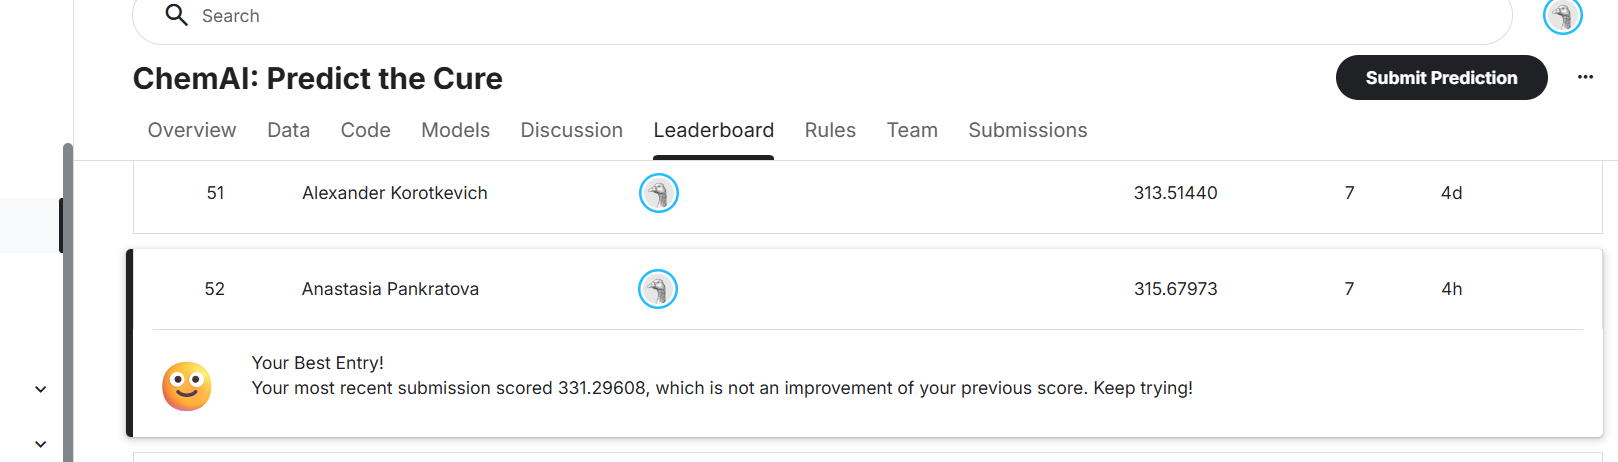